# TTM (Tiny Time Mixers) — Model Experiment
**Dataset:** Monthly Labor Market (`monthly_labor_market.csv`)  
**Target:** `EMPLOY`  
**Horizon:** 12 months  
**Split:** 80 % train / last 12 months test  
**Metrics:** MAE, MSE  
**Model:** TTM pretrained — `ibm-granite/granite-timeseries-ttm-r2`

In [1]:
# Install from source to avoid broken PyPI package:
# !pip install "tsfm_public[notebooks] @ git+https://github.com/ibm-granite/granite-tsfm.git@v0.2.18"
# Also pin transformers to avoid PreTrainedModel API changes in v5:
# !pip install "transformers>=4.38,<5.0"


In [2]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
df = pd.read_csv("../data/processed/monthly_labor_market.csv")

df.rename(columns={"date": "ds"}, inplace=True)
df["ds"] = pd.to_datetime(df["ds"], format="%Y:%m")

df = df.dropna(how="all", subset=df.columns[1:])
df = df.ffill()
df = df.dropna()

df.head()

,ds,POP,LFC,LFPART,RUC,EMPLOY,H,HG,HS
300,1964-01-01,123560.0,72356.0,58.5594,5.6,57487.0,50.8,92.4,39.3
301,1964-02-01,123707.0,72683.0,58.7542,5.4,57753.0,51.5,95.3,39.4
302,1964-03-01,123857.0,72713.0,58.7072,5.4,57897.0,51.5,95.1,39.4
303,1964-04-01,124019.0,73274.0,59.0829,5.3,57922.0,51.7,95.2,39.6
304,1964-05-01,124204.0,73395.0,59.0923,5.1,58089.0,51.9,95.6,39.6


In [4]:
TARGET = "EMPLOY"

In [5]:
HORIZON     = 12
CONTEXT_LEN = 512

split = int(len(df) * 0.8)

train_df = df.iloc[:split]
test_df  = df.iloc[split:split + HORIZON]

y_true = test_df[TARGET].values

print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)

Train shape: (596, 9)
Test shape:  (12, 9)


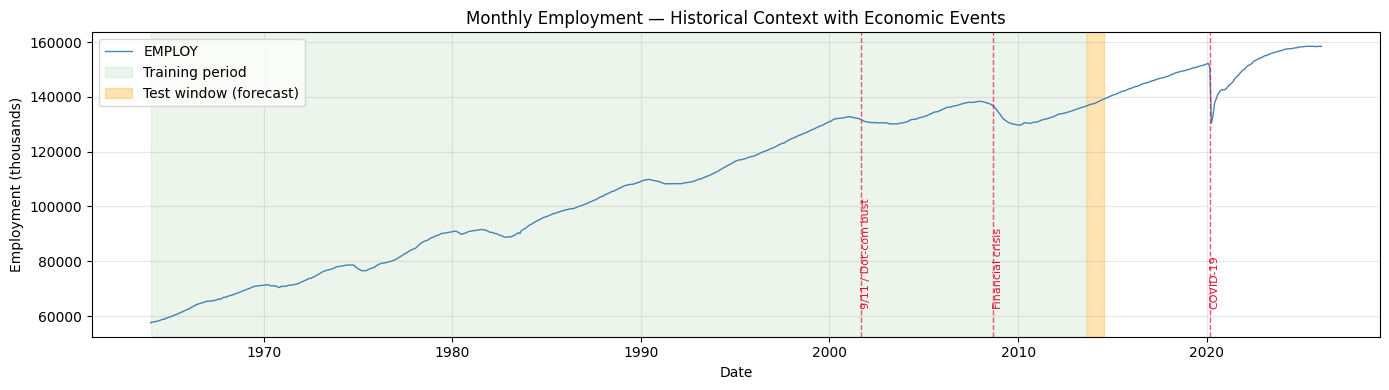

In [6]:
EVENTS = {
    "2001-09-01": "9/11 / Dot-com bust",
    "2008-09-01": "Financial crisis",
    "2020-03-01": "COVID-19",
}

y_max = df[TARGET].max()
y_min = df[TARGET].min()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["ds"], df[TARGET], color="steelblue", linewidth=1, label=TARGET)

ax.axvspan(train_df["ds"].iloc[0], train_df["ds"].iloc[-1],
           alpha=0.08, color="green", label="Training period")
ax.axvspan(test_df["ds"].iloc[0], test_df["ds"].iloc[-1],
           alpha=0.3, color="orange", label="Test window (forecast)")

for date, label in EVENTS.items():
    ts = pd.Timestamp(date)
    ax.axvline(ts, color="crimson", linestyle="--", linewidth=1, alpha=0.7)
    ax.text(ts, y_min + (y_max - y_min) * 0.05, label,
            rotation=90, fontsize=8, color="crimson", va="bottom")

ax.set_title("Monthly Employment — Historical Context with Economic Events")
ax.set_xlabel("Date")
ax.set_ylabel("Employment (thousands)")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# Import from the correct submodule (not top-level tsfm_public)
from tsfm_public.models.tinytimemixer import TinyTimeMixerForPrediction

ttm = TinyTimeMixerForPrediction.from_pretrained(
    "ibm-granite/granite-timeseries-ttm-r2",
    prediction_filter_length=HORIZON,
)
ttm.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
ttm = ttm.to(device)

print(f"TTM loaded on {device}.")

TTM loaded on cpu.


In [8]:
series = train_df[TARGET].values.astype(np.float32)

# Use the last CONTEXT_LEN time-steps as context
context = series[-CONTEXT_LEN:]

# TTM expects shape (batch, time, n_channels) — NOT (batch, channels, time)
context_tensor = torch.tensor(context, dtype=torch.float32)
context_tensor = context_tensor.unsqueeze(0).unsqueeze(-1).to(device)  # (1, T, 1)

print("Context tensor shape:", context_tensor.shape)  # should be (1, 512, 1)

Context tensor shape: torch.Size([1, 512, 1])


In [9]:
with torch.no_grad():
    output = ttm(past_values=context_tensor)

# output.prediction_outputs shape: (batch, horizon, n_channels)
ttm_pred = output.prediction_outputs[0, :HORIZON, 0].cpu().numpy()

print("Shape:     ", ttm_pred.shape)
print("Prediction:", ttm_pred)

Shape:      (12,)
Prediction: [138098.31 137928.53 137846.98 137681.95 137412.84 137313.25 137245.14
 137126.38 136943.95 136669.31 136769.17 136790.77]


In [10]:
ttm_mae = mean_absolute_error(y_true, ttm_pred)
ttm_mse = mean_squared_error(y_true, ttm_pred)
print(f"TTM  MAE: {ttm_mae:.2f}")
print(f"TTM  MSE: {ttm_mse:.2f}")

TTM  MAE: 1166.08
TTM  MSE: 1962904.24


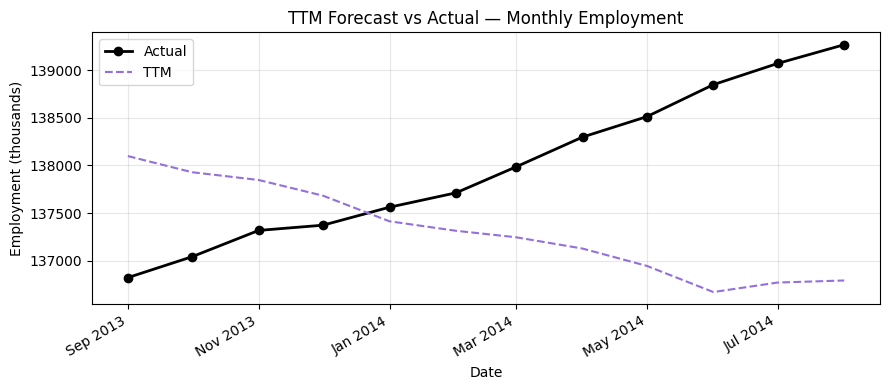


Model               MAE            MSE
--------------------------------------
TTM             1166.08     1962904.24


In [11]:
forecast_dates = test_df["ds"].values

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(forecast_dates, y_true,
        color="black", marker="o", label="Actual", linewidth=2)
ax.plot(forecast_dates, ttm_pred,
        linestyle="--", color="mediumpurple", label="TTM", linewidth=1.5)
ax.set_title("TTM Forecast vs Actual — Monthly Employment")
ax.set_xlabel("Date")
ax.set_ylabel("Employment (thousands)")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f"\n{'Model':<12} {'MAE':>10} {'MSE':>14}")
print("-" * 38)
print(f"{'TTM':<12} {ttm_mae:>10.2f} {ttm_mse:>14.2f}")